In [2]:
from pathlib import Path
import os
import sys
import numpy as np
import pickle

In [3]:
MiM_path = Path(os.getcwd()).parent
BASE = Path(MiM_path/'data')

In [ ]:
# voy a usar primero el dataset de Kaggle que es el que uso FU en https://github.com/HzFu/EyeQ/blob/master/EyeQ_preprocess/fundus_prep.py

# Importo el archivo donde tengo la ruta de cada imagen
with open(BASE/'labels/Kaggle_zhou.pkl','rb') as f:
    Zhou = pickle.load(f)


with open(BASE/'labels/DDR.pkl','rb') as f:
    DDR = pickle.load(f)


# Voy a usar una de las imagenes que uso FU
file_path = Zhou[Zhou.filename == '116_right.png'].file_path.item()
# file_path = Zhou[Zhou.filename == '42945_left.png'].file_path.item()
# file_path = DDR[DDR.filename == '007-7255-400.jpg'].file_path.item()
# file_path = DDR[DDR.filename == '007-0199-000.jpg'].file_path.item()

# Mi preprocesamiento

## 1. Importar imagen con OpenCV

In [18]:
import cv2

image = cv2.imread(file_path) # OpenCV por default importa los canales e ignora el de transparencia si existiera. Los canales son BGR
image.shape

(244, 311, 3)

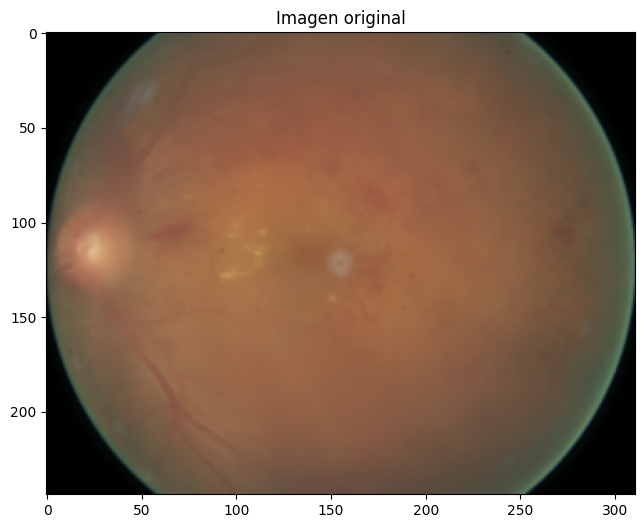

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 1, figsize=(12, 6))

axes.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB) )
axes.set_title("Imagen original")

plt.show()

## 2. Fondo blanco?

In [20]:
# Hay algunas imagenes que tienen fondo blanco que el preprocesamiento de Fu no lo soporta
# tengo que cambiar el fondo para que sea negro sino la mascara no va a funcionar

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # paso a un solo canal gris. Si el pixel es blanco entonces le queda 255 y si es negro le queda 0.

freq_intensity = np.bincount(gray.ravel().astype(np.int64)) # pone todos los valores en un solo array, ordena los valores y hace un conteo de frecuencia.

# Si la moda es el 255 entonces quiere decir que el fondo es blanco
if np.where(freq_intensity == freq_intensity.max())[0].item() == 255:
    index = np.where(gray == 255) # donde estan ubicados los pixeles blancos
    imagen_modified = image.copy()
    imagen_modified[index[0],index[1],...] = 0 # reemplazo por negro
else:
    imagen_modified = image.copy()

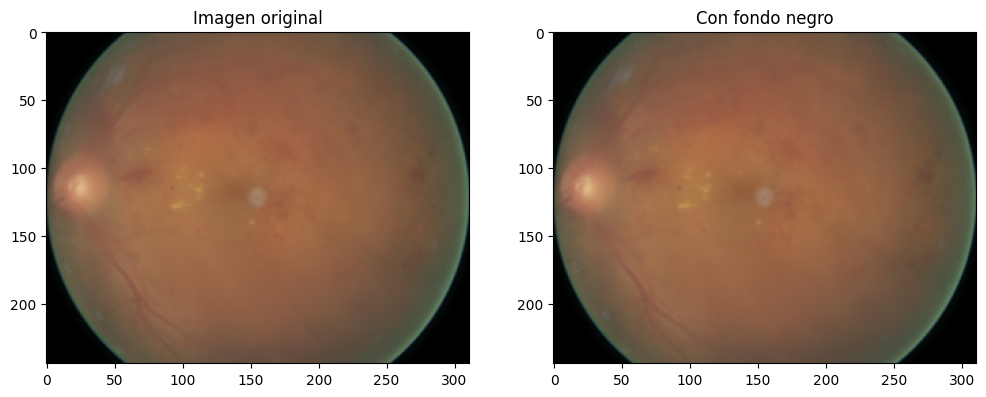

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagen original")

axes[1].imshow(cv2.cvtColor(imagen_modified, cv2.COLOR_BGR2RGB))
axes[1].set_title("Con fondo negro")

plt.show()

## 3. FOV mask

### 3.2 Detectar un circulo si fuera posible

Se aplica el desenfoque para bajar el ruido de la imagen y preservar la estructura principal.

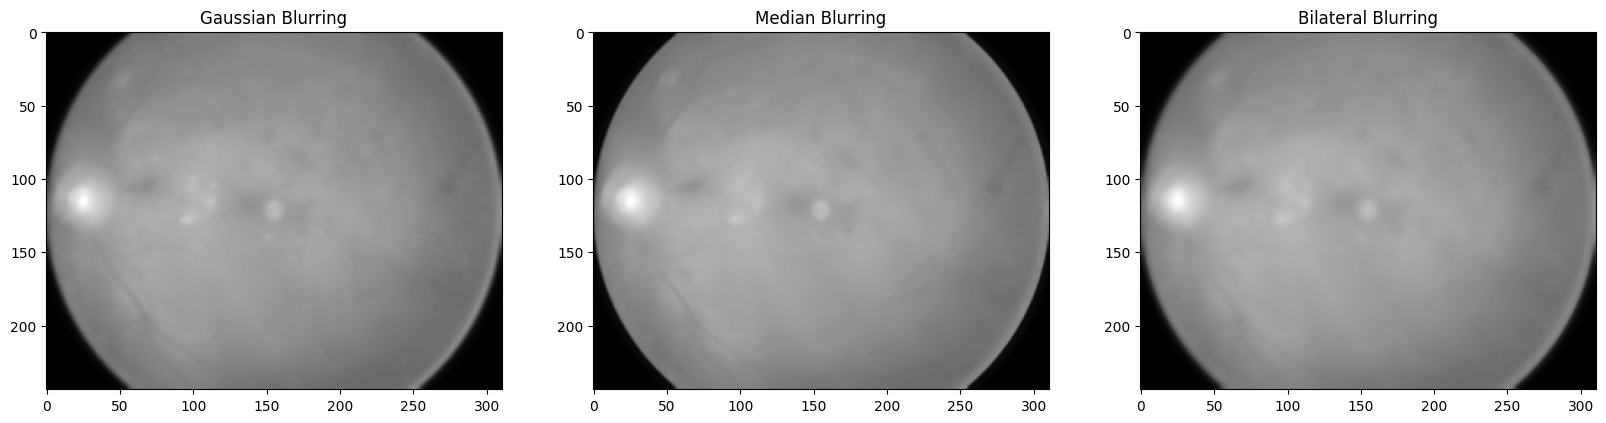

In [22]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

Gaussian = cv2.GaussianBlur(gray, (7, 7), 0) 
gray_blur = cv2.medianBlur(gray, 7)

# Median Blur: The Median Filter is a non-linear digital filtering technique, often used to remove noise from an image or signal. 
# Median filtering is very widely used in digital image processing because, under certain conditions, it preserves edges while removing noise.
# It is one of the best algorithms to remove Salt and pepper noise.

bilateral = cv2.bilateralFilter(gray, 9, 75, 75) 


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(Gaussian, cmap="gray")
axes[0].set_title("Gaussian Blurring")

axes[1].imshow(gray_blur, cmap="gray")
axes[1].set_title("Median Blurring")

axes[2].imshow(bilateral, cmap="gray")
axes[2].set_title("Bilateral Blurring")

plt.show()

In [23]:
# Buscamos si hay un circulo en la imagen
# https://docs.opencv.org/4.x/dd/d1a/group__imgproc__feature.html#ga47849c3be0d0406ad3ca45db65a25d2d
rows = gray_blur.shape[0]
cols = gray_blur.shape[1]
circles = cv2.HoughCircles(gray_blur,
                           method=cv2.HOUGH_GRADIENT,
                           dp=1,
                           minDist=cols//2, # minima distancia entre los distintos circulos. Yo quiero un solo circulo asique pongo aca un valor alto
                           param1=60, # Umbral superior de Canny (bordes). Si pongo 100, OpenCV usa como umbral inferior la mitad. Valores bajos: Detecta más bordes (más ruido). Valores altos: Solo bordes fuertes.
                           param2=30, # Umbral del acumulador de Hough. Bajo: Detecta más círculos (más falsos positivos). Alto: Solo círculos bien definidos.
                           minRadius=min(rows,cols)//4, # yo quiero detectar solo un circulo, el mejor y mas grande posible. La mayor parte de la imagen deberia ser la rutina. No creo que ninguna imagen de fondo de ojo ocupe un cuarto del total.
                           maxRadius=max(rows,cols)//2)

circles = np.uint16(np.around(circles)) # circles es dtype=float32 lo paso a int

if circles is not None and circles.shape[1] == 1:
    circle = circles[0,0]
    mask_black = np.zeros((gray_blur.shape[0],gray_blur.shape[1]),np.uint16) # creo una imagen negra donde insertar la mascara del circulo
    center = (circle[0], circle[1])
    radius = circle[2]
    cv2.circle(mask_black, center, radius, 255 , -1)

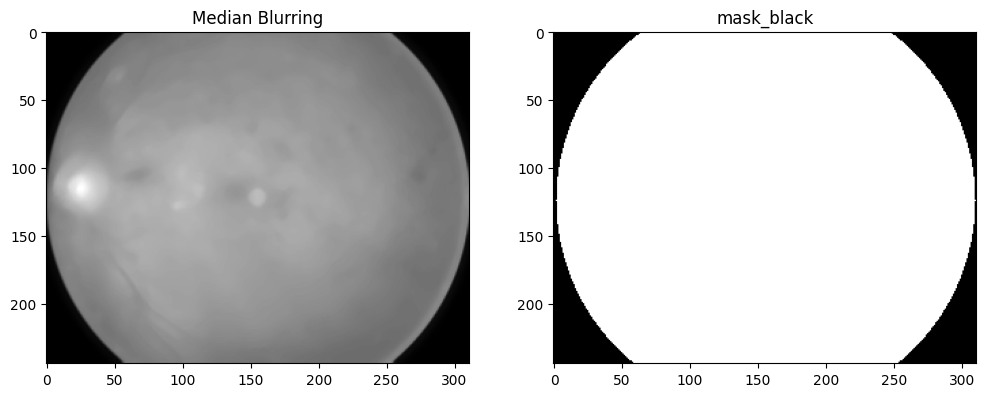

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(gray_blur, cmap="gray")
axes[0].set_title("Median Blurring")

axes[1].imshow(mask_black, cmap="gray")
axes[1].set_title("mask_black")

plt.show()

#### 3.2.1 Aplicar FOV mask

In [14]:
img_preproc = image.copy()
img_preproc[mask_black<=0,...]=0 # todos los pixeles que en la mascara son negros los pone negro tambien en la imagen asi me quedo solo con el circulo

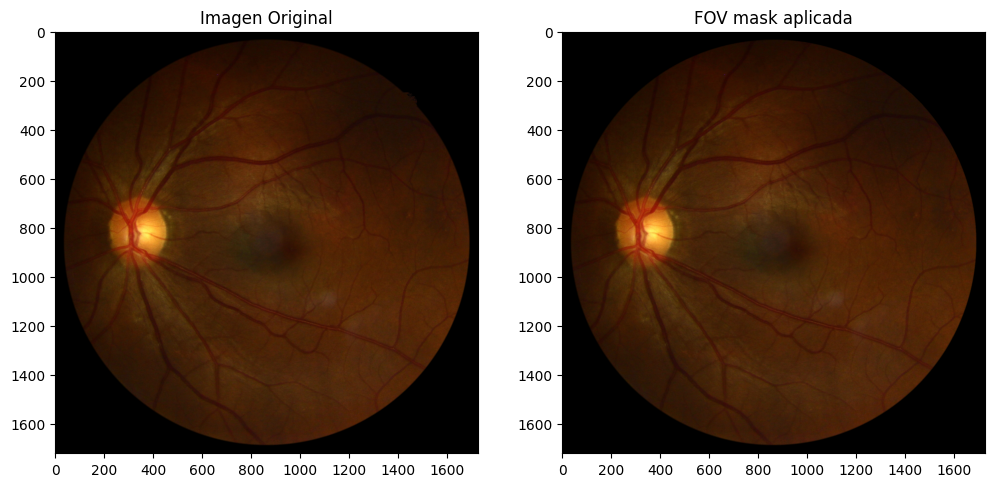

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagen Original")

axes[1].imshow(cv2.cvtColor(img_preproc, cv2.COLOR_BGR2RGB))
axes[1].set_title("FOV mask aplicada")

plt.show()

#### 3.2.2 Bounding Box

In [57]:
from skimage import measure

# regionprops devuelve caracteristicas de las categorias en una imagen binaria.
regions = measure.regionprops(np.asarray(mask_black, dtype=np.uint8))

for i, region in enumerate(regions):
    print(f"Región {i + 1}:")
    print(f" - Área: {region.area}")
    print(f" - Centroide: {region.centroid}")
    print(f" - Perímetro: {region.perimeter}")
    print(f" - Bounding Box: {region.bbox}")
    print(f" - Orientación: {region.orientation}")
    print()

Región 1:
 - Área: 66258.0
 - Centroide: (np.float64(122.27142382806605), np.float64(156.0))
 - Perímetro: 964.9259735953042
 - Bounding Box: (0, 2, 244, 311)
 - Orientación: 1.5707963267948966



#### 3.2.3 Recortar

In [58]:
coordinates = regions[0].bbox

img_preproc = img_preproc[coordinates[0]:coordinates[2],coordinates[1]:coordinates[3]]

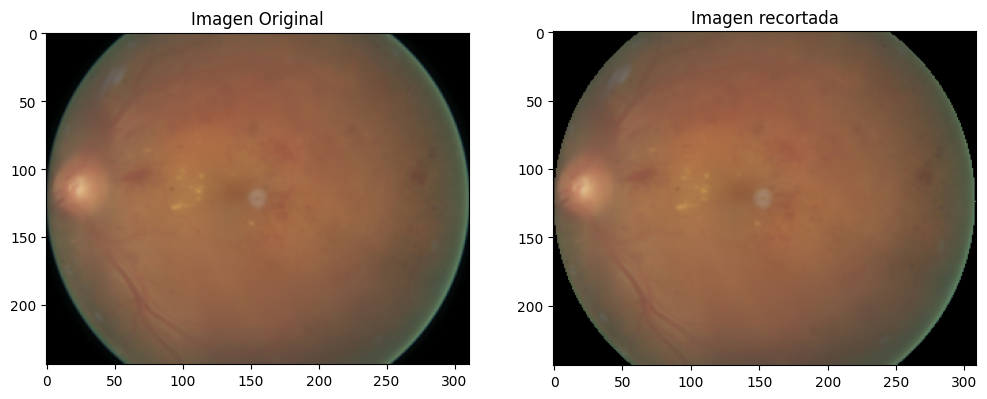

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagen Original")

axes[1].imshow(cv2.cvtColor(img_preproc, cv2.COLOR_BGR2RGB))
axes[1].set_title("Imagen recortada")

plt.show()

#### 3.2.4 Resize a 512x512

In [60]:
img_preproc = cv2.resize(img_preproc, (512, 512))

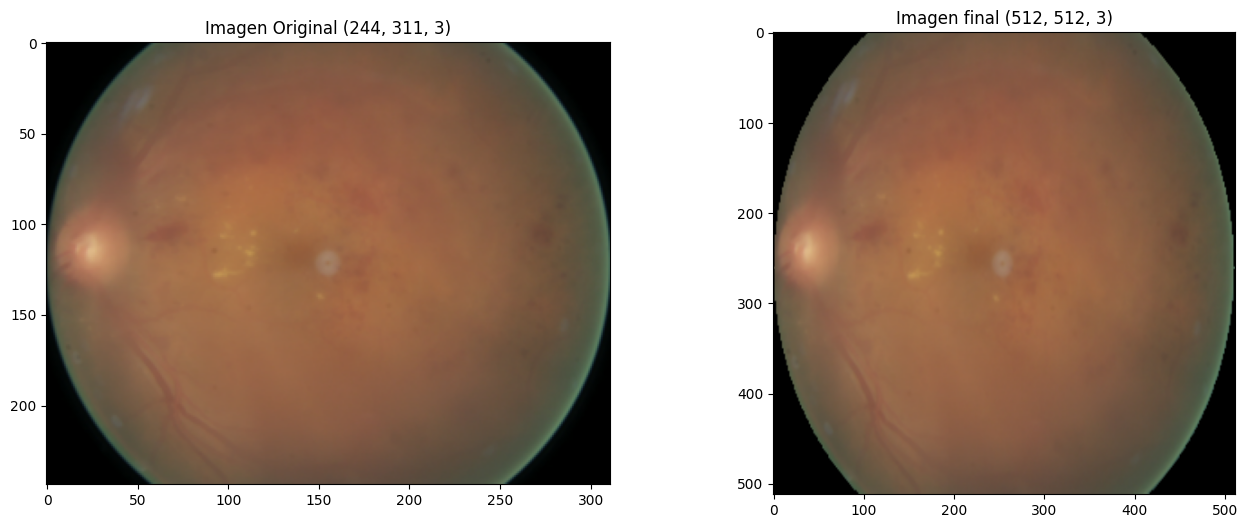

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Imagen Original {image.shape}")

axes[1].imshow(cv2.cvtColor(img_preproc, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Imagen final {img_preproc.shape}")

plt.show()

### 3.3 Si no es posible detectar un circulo

#### 3.3.1 Suma de intensidades

In [77]:
# Las fotos de fondo de ojo son imágenes a color, por lo que tienen 3 canales (R, G, B). 
# El FOV o field of view es la región de la imagen en la que hay contenido de la retina.
# Todo lo que no es FOV toma intensidades negras (es decir, muy cercanas a 0). Sin embargo,
# hay algunas cámaras de fondo de ojo en las que el negro no es tan negro, si no que las 
# intensidades tienen algo de ruido (entonces por ahí llegan al 10 o al 20, pero siempre valores bajos).
# Sumar los canales R, G, B te permite sumar las contribuciones de intensidades de los 3 canales.
# El resultado sería una imagen en la que las diferencias entre la zona con contenido de la retina y
# la que está fuera del FOV son más notorias.

## Suma los 3 canales (axis=2). También puedo pasarle el objeto de PIL "im".
sum_of_channels = np.sum(imagen_modified,axis=2) # OJO aca si pongo dtype=np.uint8 que va de 0 a 255 cuando la suma supera 255 pone 256 = 0, 257 = 1, etc.
sum_of_channels_uint8 = np.sum(imagen_modified,axis=2,dtype=np.uint8)

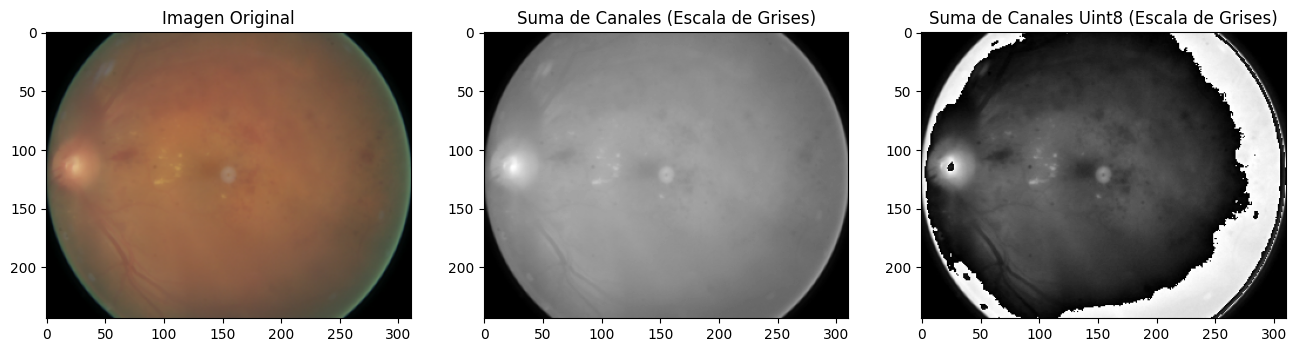

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagen Original")

axes[1].imshow(sum_of_channels, cmap="gray")
axes[1].set_title("Suma de Canales (Escala de Grises)")

axes[2].imshow(sum_of_channels_uint8, cmap="gray")
axes[2].set_title("Suma de Canales Uint8 (Escala de Grises)")


plt.show()

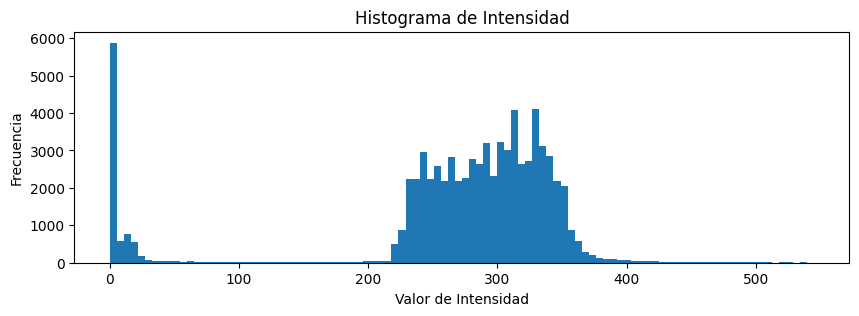

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))

ax.hist(sum_of_channels.ravel(), bins=100) # sum_of_channels tiene dos dimension, con ravel lo achata a una dimension.
ax.set_title("Histograma de Intensidad")
ax.set_xlabel("Valor de Intensidad")
ax.set_ylabel("Frecuencia")

plt.show()

# En el plot se ve que es una bimodal, un grupo reducido cerca del 0 que son en su mayoria el borde negro de la imagen y los otros
# alrededor del 300 que son los pixel que forman parte del ojo.

#### 3.3.2 Umbral OTSU

umbral del fondo: 152


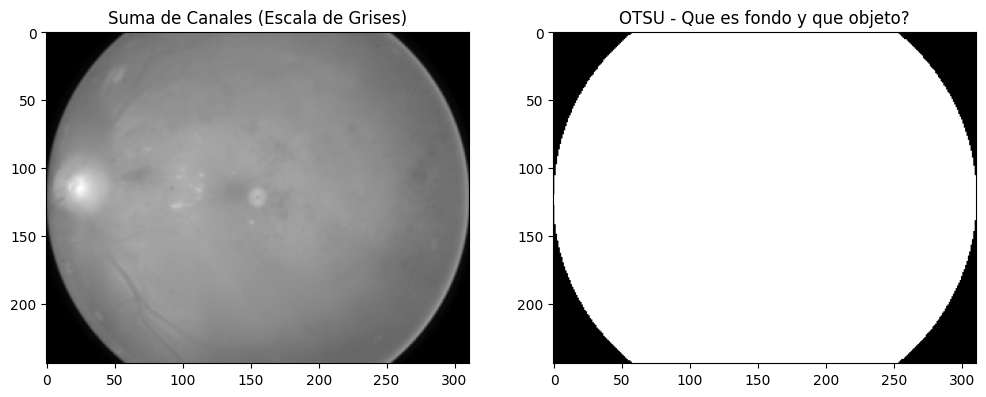

In [80]:
# El método Otsu analiza el histograma de la imagen para encontrar un valor de umbral que minimice la varianza intraclase 
# y maximice la varianza interclase, separando así de forma óptima los píxeles en dos grupos: uno que representa los objetos 
# y otro el fondo.

from skimage import filters

threshold_fondo = filters.threshold_otsu(sum_of_channels.astype(np.int64)) # lo paso a int64 porque el skimage no espera recibir tipos de datos uint64 que son solo positivos
print(f'umbral del fondo: {threshold_fondo}')

fov_mask = sum_of_channels > threshold_fondo

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(sum_of_channels, cmap="gray")
axes[0].set_title("Suma de Canales (Escala de Grises)")

axes[1].imshow(fov_mask, cmap="gray")
axes[1].set_title("OTSU - Que es fondo y que objeto?")

plt.show()

#### 3.3.3 Rellenar agujeros

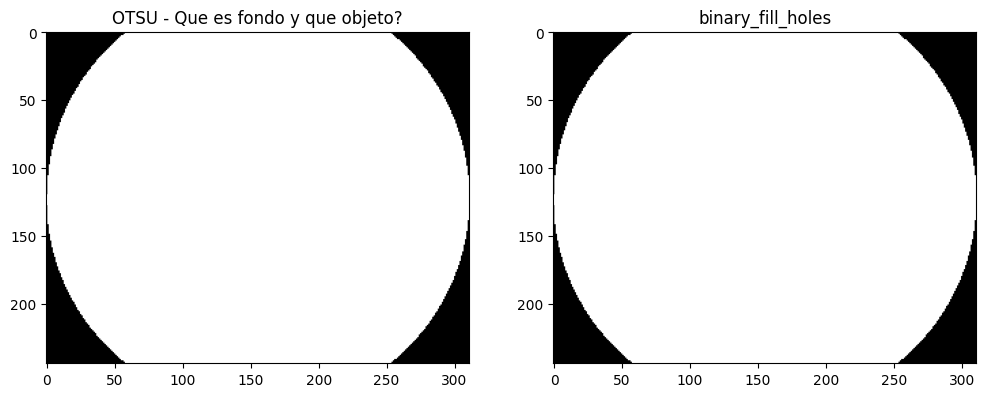

In [81]:
from scipy.ndimage import binary_fill_holes

bi = binary_fill_holes(fov_mask)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(fov_mask, cmap="gray")
axes[0].set_title("OTSU - Que es fondo y que objeto?")

axes[1].imshow(bi, cmap="gray")
axes[1].set_title("binary_fill_holes")

plt.show()

#### 3.3.4 Aplicar FOV mask

In [93]:
img_preproc = image.copy()
img_preproc[np.asarray(bi, dtype=np.uint8)<=0,...]=0 

#### 3.3.5 Bounding Box

In [94]:
from skimage import measure

# regionprops devuelve caracteristicas de las categorias en una imagen binaria.
regions = measure.regionprops(np.asarray(bi, dtype=np.uint8))

for i, region in enumerate(regions):
    print(f"Región {i + 1}:")
    print(f" - Área: {region.area}")
    print(f" - Centroide: {region.centroid}")
    print(f" - Perímetro: {region.perimeter}")
    print(f" - Bounding Box: {region.bbox}")
    print(f" - Orientación: {region.orientation}")
    print()

Región 1:
 - Área: 67201.0
 - Centroide: (np.float64(121.68128450469487), np.float64(155.34938468177558))
 - Perímetro: 972.4406922210657
 - Bounding Box: (0, 0, 244, 311)
 - Orientación: 1.5701852835190846



#### 3.3.6 Recortar

In [95]:
coordinates = regions[0].bbox

img_preproc = img_preproc[coordinates[0]:coordinates[2],coordinates[1]:coordinates[3]]

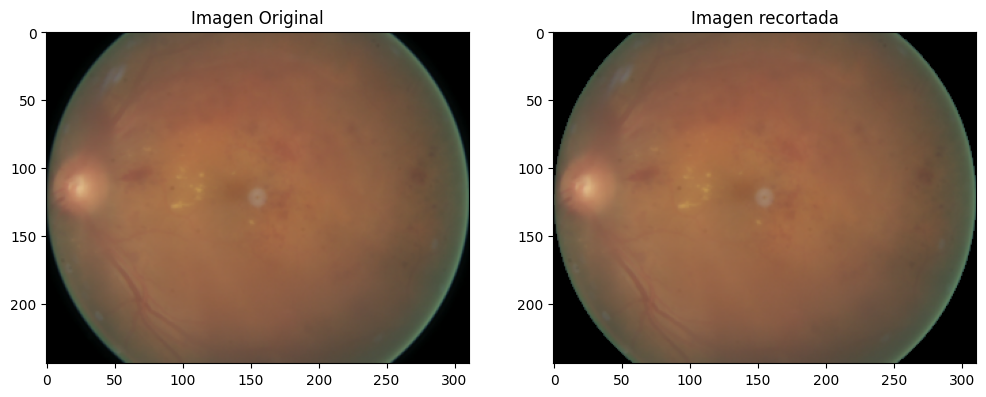

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagen Original")

axes[1].imshow(cv2.cvtColor(img_preproc, cv2.COLOR_BGR2RGB))
axes[1].set_title("Imagen recortada")

plt.show()

#### 3.3.7 Resize a 512x512

In [97]:
img_preproc = cv2.resize(img_preproc, (512, 512))

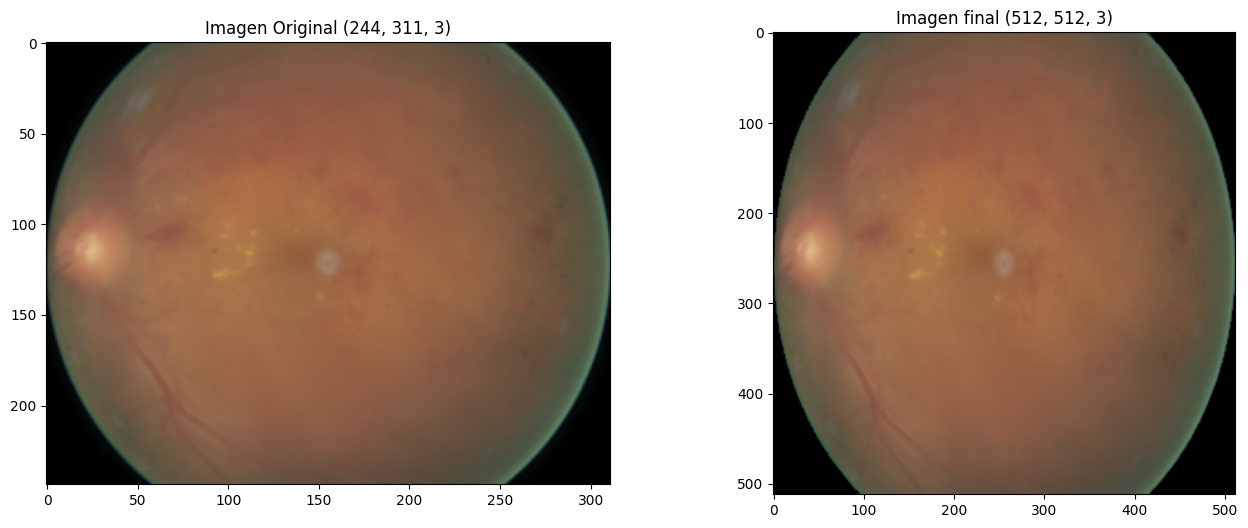

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Imagen Original {image.shape}")

axes[1].imshow(cv2.cvtColor(img_preproc, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Imagen final {img_preproc.shape}")

plt.show()

# Fu preprocesamiento

## 1. Importar imagen con OpenCV

In [433]:
import cv2

im = cv2.imread(file_path) # Carga la imagen en formato BGR (azul, verde, rojo)

In [434]:
im.ndim, im.shape

(3, (244, 311, 3))

In [435]:
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB) # pasa de BGR a RGB

## 2. FOV mask

In [436]:
g_img=cv2.cvtColor(im,cv2.COLOR_RGB2GRAY) # pasa a escala de grises Y=0.2989⋅R+0.5870⋅G+0.1140⋅B 
                                          # Esta fórmula refleja cómo el ojo humano percibe la luminosidad,
                                          # dando más peso al verde (0.5870) y menos al azul (0.1140).

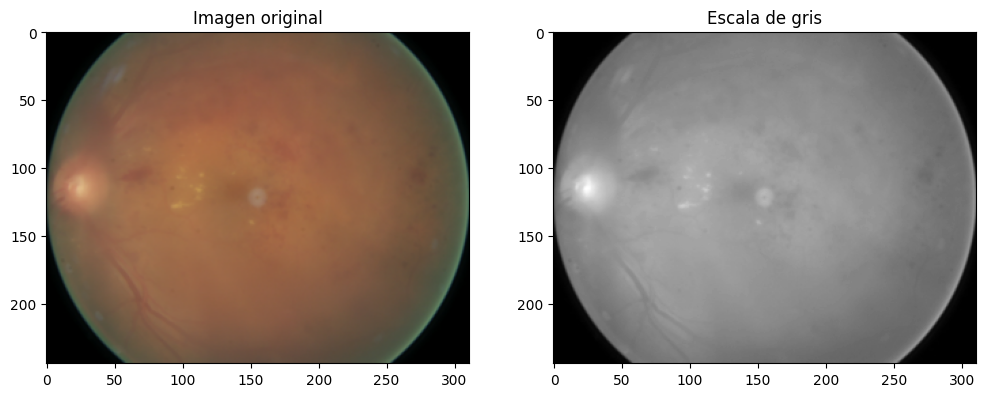

In [437]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(im)
axes[0].set_title("Imagen original")

axes[1].imshow(g_img, cmap="gray")
axes[1].set_title("Escala de gris")

plt.show()

In [438]:
h,w = g_img.shape
shape = g_img.shape[0:2] # no se para que aclara los indices si van a ser esos solamente
g_img = cv2.resize(g_img,(0,0),fx = 0.5,fy = 0.5) # el segundo parametro es el tamaño al que quiere resizear pero como pone (0,0)
                                                  # la funcion ignora ese parametro y usa fx y fy. Esta achicando a la mitad ambos ejes.

print(g_img.shape)
# motivos para achicar a la mitad la imagen:
# bajar el costo computacional. Ahora la imagen tiene 4 veces menos pixeles
# Si la imagen tiene ruido o pequeños detalles innecesarios, reducirla suaviza la imagen y ayuda a evitar que 
# la segmentación se vea afectada por píxeles aislados.
# mejora la estabilidad de la detección del centro y radio

# DIFF: yo no achique la imagen

(122, 156)


In [439]:
# normalizar los valores de los píxeles de una imagen dentro de un rango específico.
tg_img=cv2.normalize(g_img, None, 0, 255, cv2.NORM_MINMAX) # la imagen va a tener de 0 a 255 y escala proporcionalmente los valores
                                                           # intermedios con minmax

# DIFF: no normalice en este punto porque quiero agrandar lo mas posible el contrastre entre fondo y objeto

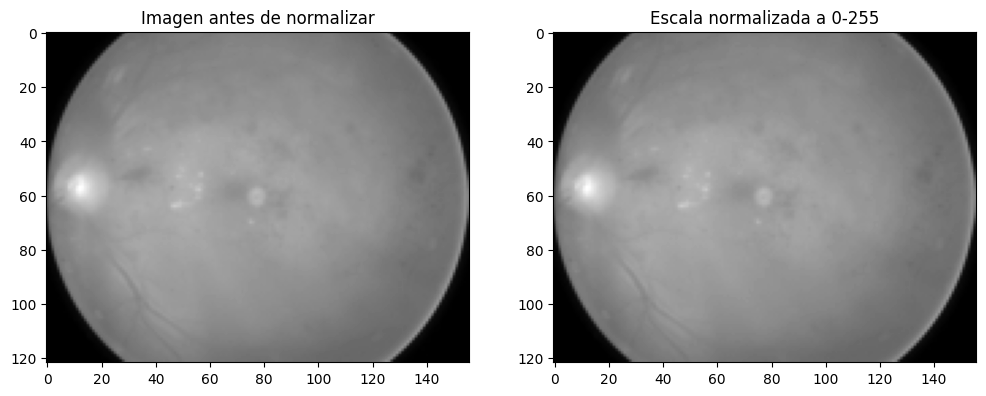

In [440]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(g_img, cmap="gray")
axes[0].set_title("Imagen antes de normalizar")

axes[1].imshow(tg_img, cmap="gray")
axes[1].set_title("Escala normalizada a 0-255")

plt.show()

### 2.1 Umbral

In [441]:
gray_img = tg_img
threhold = np.mean(gray_img)/3-5 # umbral
print(threhold)

36.11801176965111


In [442]:
# crea una máscara binaria, pixeles mayores al threshold = 1 sino 0
# devuelve el threshold y la mascara
_, mask = cv2.threshold(gray_img, max(0,threhold), 1, cv2.THRESH_BINARY) # para que pone max(0, threhold)? si siempre va a ser mayor a 0 ?? 

In [443]:
# crea una mascara de ceros y con dos pixeles extras de alto y ancho. Es
# una imagen toda negra
nn_mask = np.zeros((mask.shape[0]+2,mask.shape[1]+2),np.uint8)

In [444]:
# invierte la imagen, para que el fondo ahora sea blanco (1)
new_mask = (1-mask).astype(np.uint8)

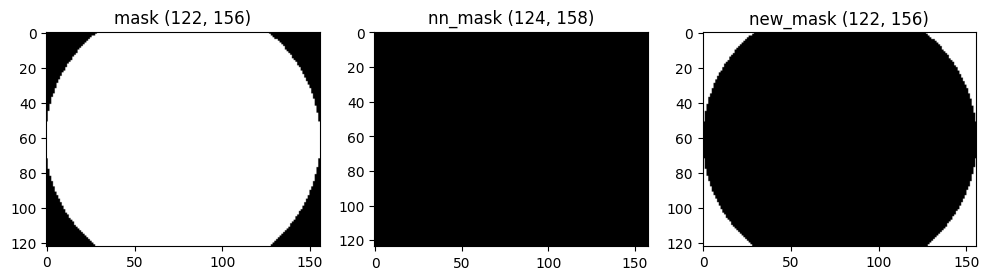

In [445]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(mask, cmap="gray")
axes[0].set_title(f"mask {mask.shape}")

axes[1].imshow(nn_mask, cmap="gray")
axes[1].set_title(f"nn_mask {nn_mask.shape}")

axes[2].imshow(new_mask, cmap="gray")
axes[2].set_title(f"new_mask {new_mask.shape}")

plt.show()

In [446]:
# La función cv2.floodFill() rellena una región de la imagen a partir de un punto semilla.
# Se usa para detectar y marcar áreas conectadas de píxeles con valores similares.
# new_mask Es la imagen en la que se va a aplicar el "relleno".
# nn_mask Es una máscara auxiliar que OpenCV usa internamente para evitar que la función se salga de los límites de la imagen.
# Requiere que sea dos pixeles mas de ancho y alto.
# (0,0) Es el punto semilla, es decir, el píxel desde donde empieza a rellenar (seria la esquina superior izquierda de la imagen).
# (0)  Es el nuevo valor que se asignará a los píxeles rellenos, o sea le va a poner negro.

_,new_mask,_,_ = cv2.floodFill(new_mask, nn_mask, (0,0), (0), cv2.FLOODFILL_MASK_ONLY)


# Esta parte del preprocesamiento no aceptaria imagenes con fondos blancos

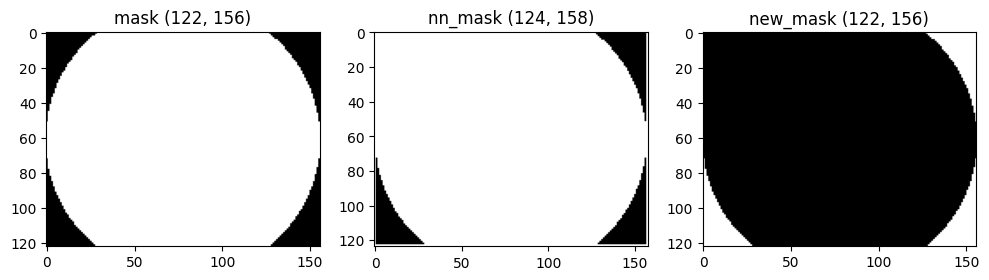

In [447]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(mask, cmap="gray")
axes[0].set_title(f"mask {mask.shape}")

axes[1].imshow(nn_mask, cmap="gray")
axes[1].set_title(f"nn_mask {nn_mask.shape}")

axes[2].imshow(new_mask, cmap="gray")
axes[2].set_title(f"new_mask {new_mask.shape}")

plt.show()

In [448]:
_,new_mask,_,_ = cv2.floodFill(new_mask, nn_mask, (new_mask.shape[1]-1,new_mask.shape[0]-1), (0), cv2.FLOODFILL_MASK_ONLY)

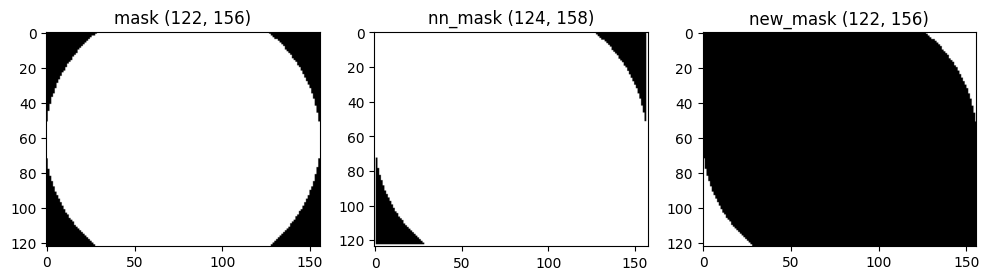

In [449]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(mask, cmap="gray")
axes[0].set_title(f"mask {mask.shape}")

axes[1].imshow(nn_mask, cmap="gray")
axes[1].set_title(f"nn_mask {nn_mask.shape}")

axes[2].imshow(new_mask, cmap="gray")
axes[2].set_title(f"new_mask {new_mask.shape}")

plt.show()

In [450]:
mask = mask + new_mask

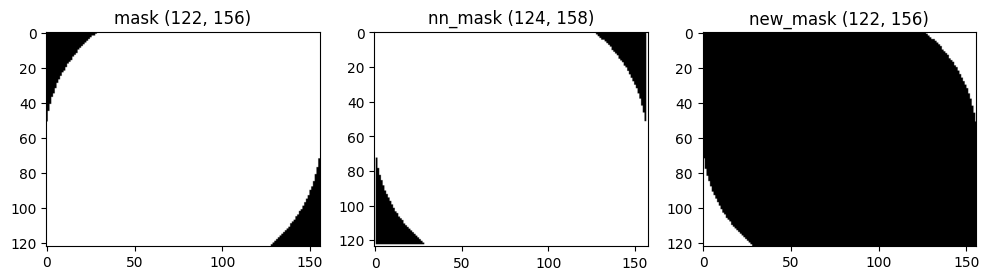

In [451]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(mask, cmap="gray")
axes[0].set_title(f"mask {mask.shape}")

axes[1].imshow(nn_mask, cmap="gray")
axes[1].set_title(f"nn_mask {nn_mask.shape}")

axes[2].imshow(new_mask, cmap="gray")
axes[2].set_title(f"new_mask {new_mask.shape}")

plt.show()

In [452]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (20,  20))
mask = cv2.erode(mask, kernel)

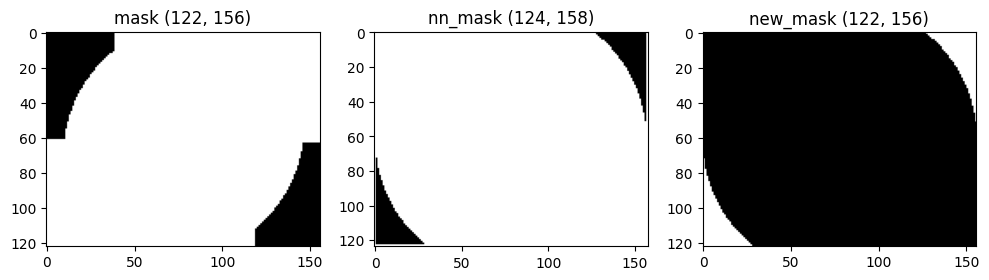

In [453]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(mask, cmap="gray")
axes[0].set_title(f"mask {mask.shape}")

axes[1].imshow(nn_mask, cmap="gray")
axes[1].set_title(f"nn_mask {nn_mask.shape}")

axes[2].imshow(new_mask, cmap="gray")
axes[2].set_title(f"new_mask {new_mask.shape}")

plt.show()

In [454]:
mask = cv2.dilate(mask, kernel)

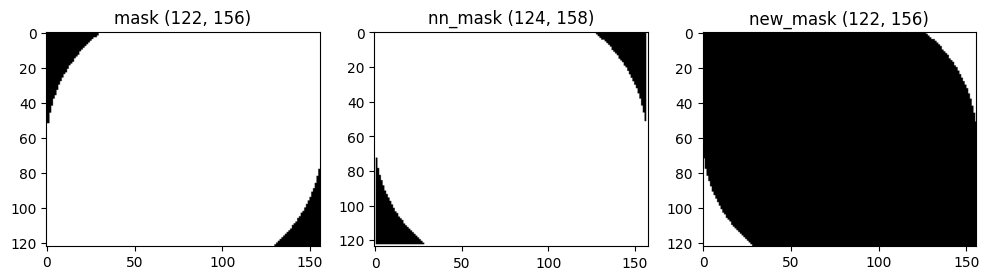

In [455]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(mask, cmap="gray")
axes[0].set_title(f"mask {mask.shape}")

axes[1].imshow(nn_mask, cmap="gray")
axes[1].set_title(f"nn_mask {nn_mask.shape}")

axes[2].imshow(new_mask, cmap="gray")
axes[2].set_title(f"new_mask {new_mask.shape}")

plt.show()

### 2.2 Bordes del ojo

In [456]:
center = [0,0]
x = mask.sum(axis=1) # suma por filas, es decir elimina las columnas
center[0]=np.where(x>x.max()*0.95)[0].mean()
print(f'coordenada y del centro: {center[0]}')

coordenada y del centro: 63.5


In [457]:
# cómo intenta encontrar el centro:
# mask es un mascara binaria entonces al sumar esta contando cuantos pixeles por linea son blancos
x

array([126, 126, 127, 129, 130, 131, 132, 133, 134, 135, 136, 137, 137,
       138, 139, 140, 140, 141, 142, 143, 143, 144, 144, 145, 146, 146,
       147, 147, 148, 148, 149, 149, 149, 150, 150, 150, 151, 151, 152,
       152, 152, 152, 153, 153, 153, 153, 154, 154, 154, 154, 154, 154,
       156, 156, 156, 156, 156, 156, 156, 156, 156, 156, 156, 156, 156,
       156, 156, 156, 156, 156, 156, 156, 156, 156, 156, 156, 156, 156,
       155, 155, 155, 155, 154, 154, 154, 154, 153, 153, 153, 152, 152,
       151, 151, 151, 150, 150, 149, 149, 148, 148, 147, 147, 146, 145,
       145, 144, 143, 143, 142, 141, 140, 140, 139, 138, 137, 136, 135,
       134, 133, 132, 131, 130], dtype=uint64)

In [458]:
# despues se fija cuales de esas lineas tiene mas del 95% del la linea que tiene el maximo numero de pixeles en blanco
# esto es para ver las lineas que en su mayoria son blancas
x>x.max()*0.95

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False])

In [459]:
# despues se queda con la posición de los True
np.where(x>x.max()*0.95)

(array([30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46,
        47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63,
        64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80,
        81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97]),)

In [460]:
# ahora que tiene la ubicación de las lineas que en su mayoria son pixeles blancos,
# asume que por ahí tiene que estar el centro de la imagen, entonces saca la media
# como para centralizar en un punto
np.where(x>x.max()*0.95)[0].mean()

np.float64(63.5)

In [461]:
# hace lo mismo pero a nivel de las columnas
x=mask.sum(axis=0)
center[1]=np.where(x>x.max()*0.95)[0].mean()
print(f'coordenada x del centro: {center[1]}')

coordenada x del centro: 79.5


In [462]:
mask_ant =  mask # no esta en el codigo de Fu pero lo agrego para graficarlo

mask = mask.astype(np.uint8) # esto ya lo tenemos asi, lo debe agregar para asegurarse el formato

ksize = max(mask.shape[1]//400*2+1,3) # si la imagen de ancho es mas grande que 400 esto puede dar mas que 3 pero en el ejemplo da 3

kernel=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(ksize,ksize)) #genera un kernel (una matriz) de forma elíptica con tamaño (ksize, ksize).
mask=cv2.morphologyEx(mask, cv2.MORPH_GRADIENT, kernel) # aplica el kernel para encontrar los bordes del objeto

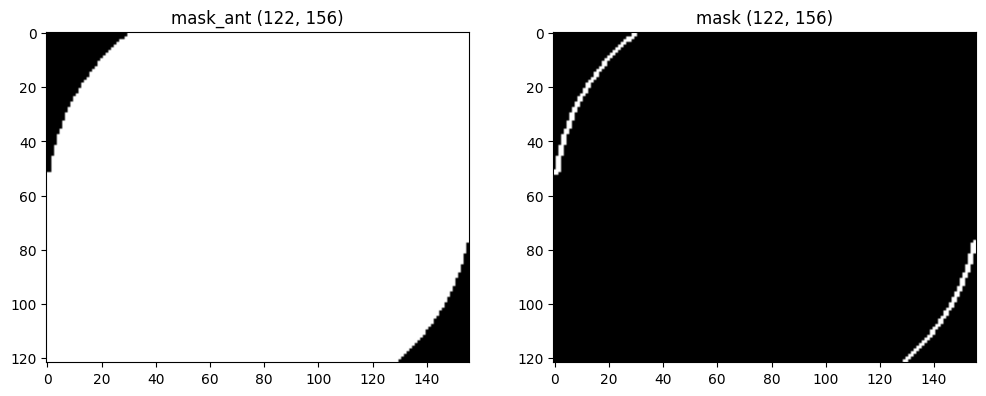

In [463]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(mask_ant, cmap="gray")
axes[0].set_title(f"mask_ant {mask_ant.shape}")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title(f"mask {mask.shape}")

plt.show()

### 2.3 Centro y Radio

In [464]:
# radius=
index=np.where(mask>0)
d_int=np.sqrt((index[0]-center[0])**2+(index[1]-center[1])**2) # distancia Euclidiana de cada punto blanco en la máscara respecto al centro
b_count=np.bincount(np.ceil(d_int).astype(np.int64)) # calcula un histograma de distancias
radius=np.where(b_count>b_count.max()*0.995)[0].max() # b_count.max() calcula la moda, multiplica por 0.995 para agarrar las distancias mas frecuentes en ese umbral

# radius es el índice de la mayor distancia que tiene más del 99.5% de las ocurrencias del valor máximo en b_count.
# Es un valor de distancia que tiene una alta frecuencia en los puntos blancos de la máscara.

In [465]:
# ajusta el centro y radio a las dimensiones originales de la imagen
center = [center[0]*2,center[1]*2]
radius = int(radius*2)

## 3. Bounding Box

In [466]:
s_h = max(0,int(center[0] - radius))
s_w = max(0, int(center[1] - radius))
s_h,s_w

(0, 0)

In [467]:
bbox = (s_h, s_w, min(h-s_h,2 * radius), min(w-s_w,2 * radius))
bbox

(0, 0, 244, 311)

### 3.1 Circulo Bbox

In [468]:
center_mask=np.zeros(shape=shape).astype('uint8') # del tamaño original hace una mascara negra
tmp_mask=np.zeros(shape=bbox[2:4])
center_tmp=(int(center[0]),int(center[1]))
center_mask=cv2.circle(center_mask,center_tmp[::-1],int(radius),(1),-1) # El segundo argumento es el centro del círculo. Se pasa center_tmp[::-1] 
                                                                        # (que es una tupla con las coordenadas del centro invertidas). 
                                                                        # Esto se hace porque OpenCV usa primero las coordenadas (x, y), mientras que en 
                                                                        # muchas otras representaciones, como en numpy, las coordenadas estan como (y, x)
                                                                        # El cuarto argumento es el color del círculo ( 1 = blanco).
                                                                        # el ultimo argumento es para rellenar el circulo

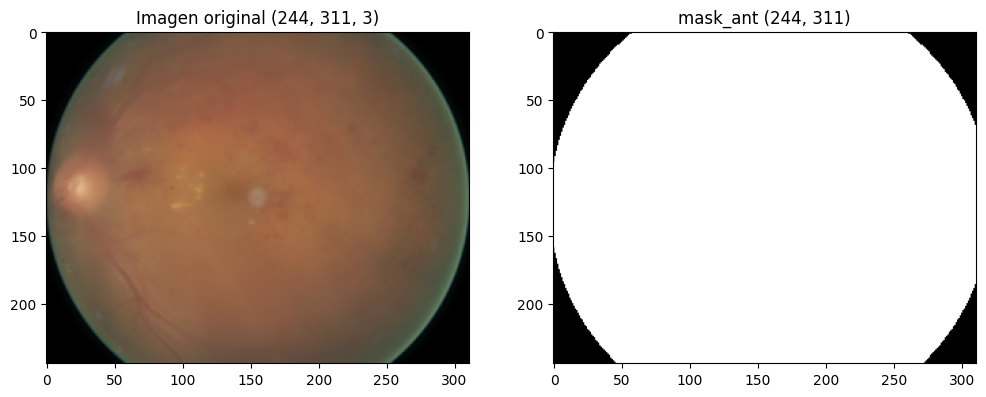

In [469]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(im)
axes[0].set_title(f"Imagen original {im.shape}")

axes[1].imshow(center_mask, cmap="gray")
axes[1].set_title(f"mask_ant {center_mask.shape}")

plt.show()

In [470]:
mask = center_mask

In [471]:
img = im.copy()
img[mask<=0,...]=0 # todos los pixeles que en la mascara son negros los pone negro tambien en la imagen.

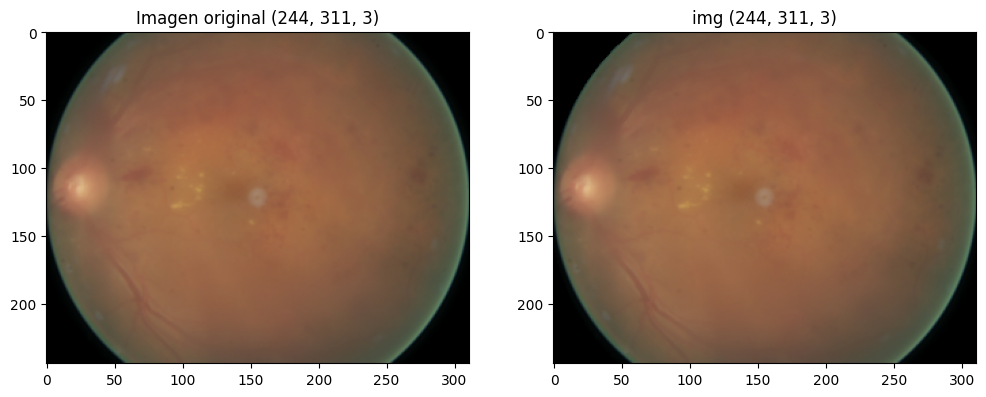

In [472]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(im)
axes[0].set_title(f"Imagen original {im.shape}")

axes[1].imshow(img)
axes[1].set_title(f"img {img.shape}")

plt.show()

## 4. Recortar
Recorta la imagen alrededor del bbox (no el circular)

In [473]:
bbox

(0, 0, 244, 311)

In [474]:
np.array((bbox[0],bbox[0]+bbox[2],bbox[1],bbox[1]+bbox[3],img.shape[0],img.shape[1]),dtype=np.int64)

array([  0, 244,   0, 311, 244, 311])

In [475]:
image=img
border=np.array((bbox[0],bbox[0]+bbox[2],bbox[1],bbox[1]+bbox[3],img.shape[0],img.shape[1]),dtype=np.int64)
r_img=image[border[0]:border[1],border[2]:border[3],...]

In [476]:
mask=mask[border[0]:border[1],border[2]:border[3],...] # tambien recorta la mascara para que queden del mismo tamaño

In [477]:
image = r_img

h,v = r_img.shape[0:2]
max_l = max(h,v) # el lado mas grande

h,v,max_l

(244, 311, 311)

In [478]:
image=np.zeros(shape=[max_l,max_l,img.shape[2]],dtype=img.dtype) # esta armando una imagen negra con mismo tamaño para h y w
print(image.shape)

border=(int(max_l/2 - h/2), int(max_l/2-h/2) + h,int(max_l/2-v/2),int(max_l/2-v/2)+v,max_l) # esto es para poder colocar centrada r_img dentro de la imagen negra
border

(311, 311, 3)


(33, 277, 0, 311, 311)

In [479]:
image[border[0]:border[1],border[2]:border[3],...]=r_img 

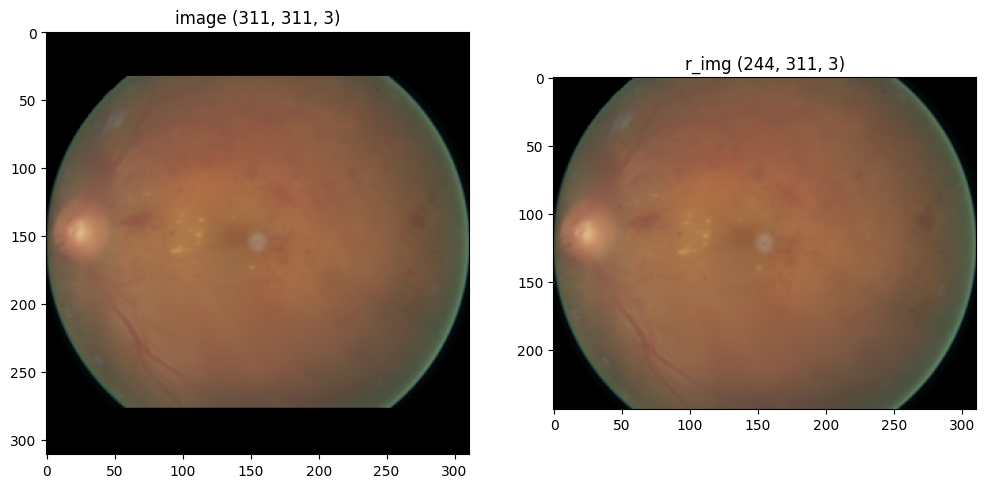

In [480]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image)
axes[0].set_title(f"image {image.shape}")

axes[1].imshow(r_img)
axes[1].set_title(f"r_img {r_img.shape}")

plt.show()

In [481]:
# lo mismo hace con la mascara
max_l=border[4]
mask_black=np.zeros(shape=[max_l,max_l],dtype=img.dtype)
mask_black[border[0]:border[1],border[2]:border[3],...]=mask

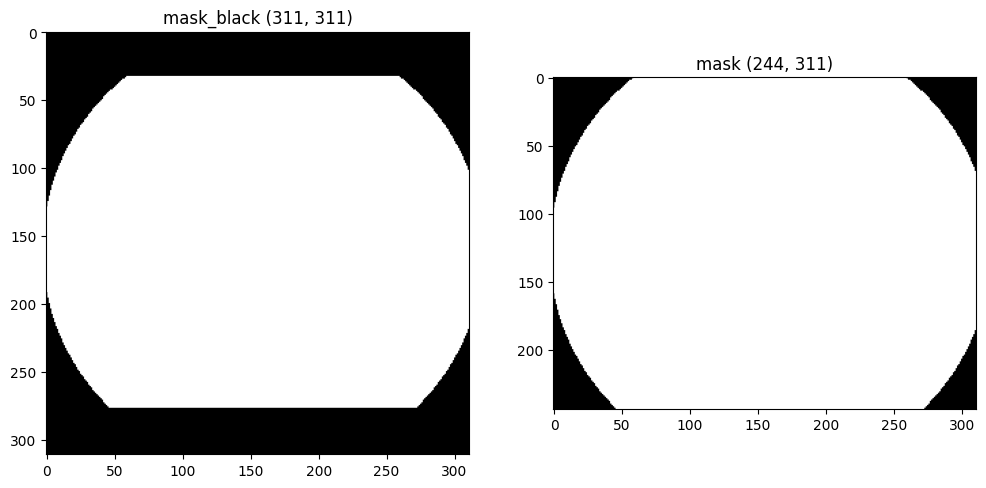

In [482]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(mask_black, cmap="gray")
axes[0].set_title(f"mask_black {mask_black.shape}")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title(f"mask {mask.shape}")

plt.show()

## 5. Resize a 800x800

In [483]:
r_img = cv2.resize(r_img, (800, 800))

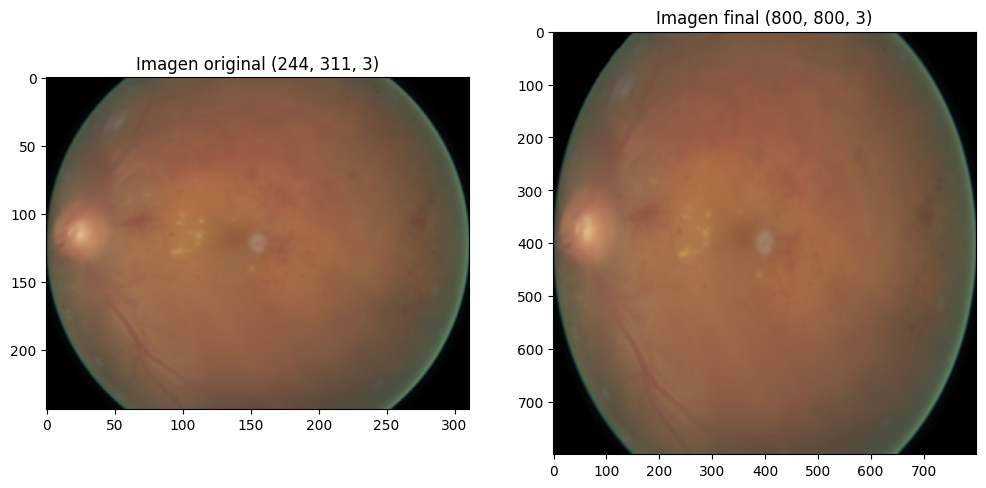

In [484]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(im)
axes[0].set_title(f"Imagen original {im.shape}")

axes[1].imshow(r_img)
axes[1].set_title(f"Imagen final {r_img.shape}")

plt.show()